In [1]:
"""
Detector Bias Voltage Characterization
=======================================
Produces:
  - Figure 3.4: Ion count rate vs. detector bias voltage (main text, §3.4.2)
  - Figure A.2: Average pulse amplitude vs. detector bias voltage (Appendix A.1)

Also contains a supporting dark-count / TDC-noise analysis used only to derive
the threshold comparison quoted in text (§3.4.2): the 18.8 Hz noise floor at a
5 mV MPANT threshold vs. 0.011 Hz at 7 mV, and the ~0.01 Hz residual detector
dark-count rate at 7 mV. That analysis does not feed any figure or exported
table in this notebook.
"""

import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

In [2]:
def read_mpa_file(filepath):
    """Reads an MPA file and returns (realtime, totalsum) from its ASCII header."""
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum


def get_hv(filename):
    """Extracts the detector bias voltage (V, returned negative) from a HV*.mpa filename."""
    name_only = filename.replace("HV", "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return -int(name_only)


def get_run(filename):
    """Extracts the run number from a HV*.mpa filename (defaults to 1 if unlabeled)."""
    name_only = filename.replace("HV", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1


def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)


def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing

In [3]:
data_folder = "HVControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)
    hv = get_hv(filename)
    run = get_run(filename)

    if run not in (5, 6, 7, 8):
        continue

    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"BAD FILE: {filename}  (realtime={realtime}, totalsum={totalsum})")
        continue  # skip it for now so you can see ALL bad files in one pass, not just the first

    rate = totalsum / realtime
    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

df = pd.DataFrame(rows).sort_values(["run", "hv_volts"]).reset_index(drop=True)

In [4]:
"""
Supporting analysis: MPANT threshold noise comparison (5 mV vs 7 mV)
----------------------------------------------------------------------
Used only to derive the dark-count/noise-floor figures quoted in §3.4.2
(18.8 Hz noise floor at 5 mV threshold; 0.011 Hz TDC noise and ~0.01 Hz
residual detector dark-count rate at 7 mV). Not plotted or exported here,
and not used to correct Figure 3.4 (Figure 3.4 is the raw run-8 bias scan
with no dark-count subtraction, per §3.4.2 of the dissertation).
"""

def get_tdc_threshold(filename):
    name_only = filename.replace("TDCNoise", "").replace(".mpa", "")
    return int(name_only)

def get_dark_info(filename):
    name_only = filename.replace("DarkCount", "").replace(".mpa", "")
    hv_str, threshold_str = name_only.split("_")
    return int(hv_str), int(threshold_str)

tdc_noise_lookup = {}
for filepath in glob.glob(os.path.join(data_folder, "TDCNoise*.mpa")):
    filename = os.path.basename(filepath)
    threshold_mv = get_tdc_threshold(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime
    err = np.sqrt(totalsum) / realtime
    tdc_noise_lookup[threshold_mv] = (rate, err)

dark_rows = []
for filepath in glob.glob(os.path.join(data_folder, "DarkCount*.mpa")):
    filename = os.path.basename(filepath)
    hv, threshold_mv = get_dark_info(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime
    err = np.sqrt(totalsum) / realtime
    dark_rows.append({
        "hv_volts": hv,
        "threshold_mv": threshold_mv,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate,
        "rate_err_hz": err
    })

dark_df = pd.DataFrame(dark_rows).sort_values(["threshold_mv", "hv_volts"]).reset_index(drop=True)
dark_df['tdc_noise_rate'] = dark_df['threshold_mv'].map(lambda t: tdc_noise_lookup[t][0])
dark_df['tdc_noise_err'] = dark_df['threshold_mv'].map(lambda t: tdc_noise_lookup[t][1])
dark_df['rate_minus_tdc_hz'] = dark_df['rate_hz'] - dark_df['tdc_noise_rate']

dark_fits = {}
dark_fits_rms = {}

for threshold_mv, group in dark_df.groupby("threshold_mv"):
    coeffs = np.polyfit(group["hv_volts"], group["rate_minus_tdc_hz"], 1)
    fit = np.poly1d(coeffs)
    residuals = group["rate_minus_tdc_hz"] - fit(group["hv_volts"])
    dark_fits[threshold_mv] = fit
    dark_fits_rms[threshold_mv] = np.sqrt(np.mean(residuals**2))

dark_df['total_error_hz'] = np.sqrt(
    dark_df['rate_err_hz']**2
    + dark_df['tdc_noise_err']**2
    + dark_df['threshold_mv'].map(lambda t: dark_fits_rms[t])**2
)

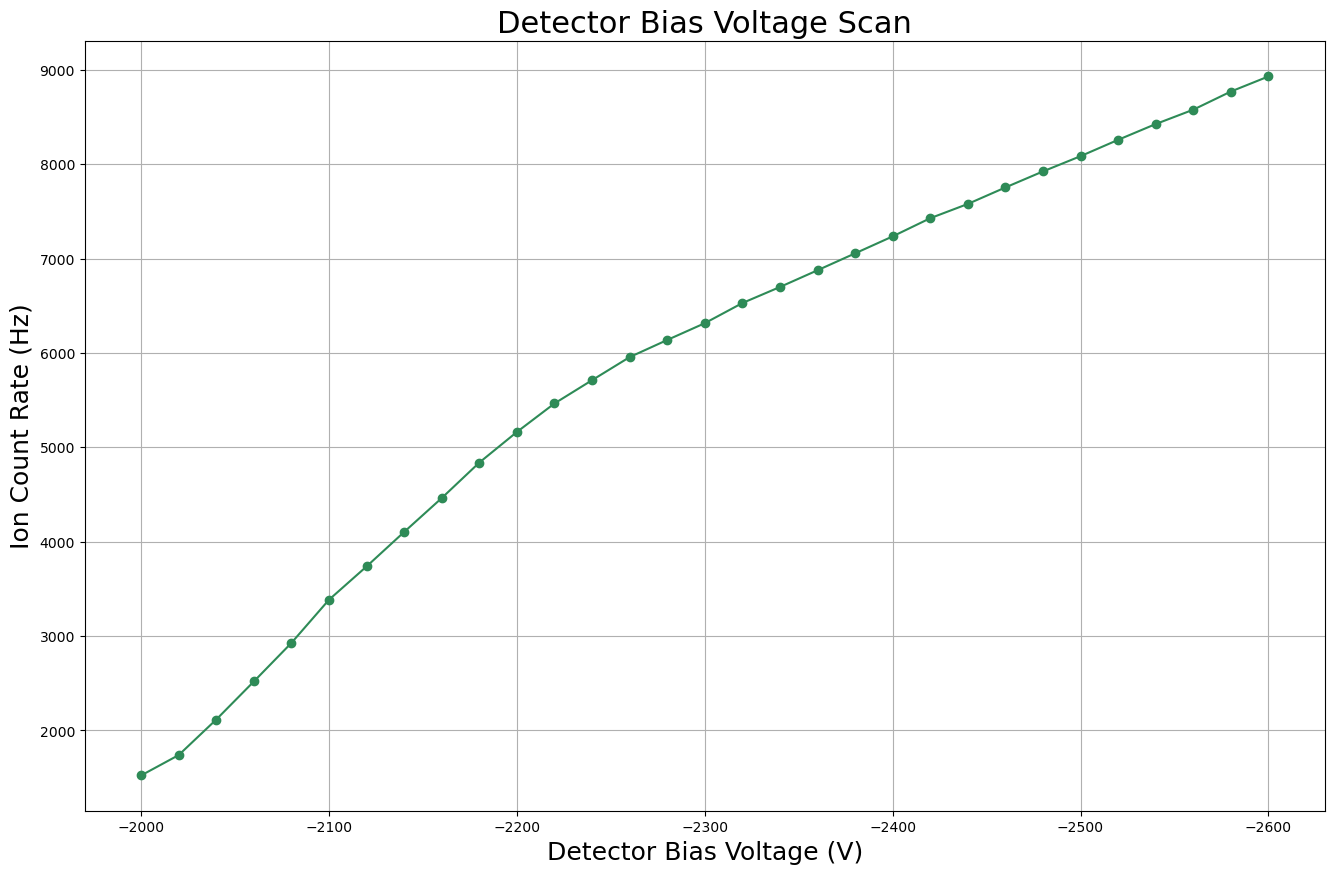

In [5]:
"""
Figure 3.4: Ion Count Rate vs. Detector Bias Voltage
-----------------------------------------------------
Run 8 of the HV scan: bias swept from -2000 to -2600 V at fixed source
output and a 7 mV MPANT threshold, using the 1.12 mm readout aperture.
This is the raw, uncorrected rate — no plateau was observed, so no
dark-count/TDC-noise correction is applicable here (see §3.4.2).
"""

run8 = df[df["run"] == 8].copy()
run8["rate_err_hz"] = np.sqrt(run8["totalsum"]) / run8["realtime_s"]

fig, ax = plt.figure(figsize=(16, 10)), plt.gca()
ax.errorbar(run8["hv_volts"], run8["rate_hz"], yerr=run8["rate_err_hz"],
            fmt="o-", color="seagreen", capsize=3)
ax.invert_xaxis()
ax.set_xlabel("Detector Bias Voltage (V)", fontsize=18)
ax.set_ylabel("Ion Count Rate (Hz)", fontsize=18)
ax.set_title("Detector Bias Voltage Scan", fontsize=22)
ax.grid(True)
plt.show()

In [6]:
description = [
    "Ion Count Rate vs. Detector Bias Voltage",
    "Corresponds to Figure 3.4",
    "",
    "Purpose: to select an operating bias voltage for the MagneTOF detector.",
    "Detector gain depends on bias voltage; the standard approach is to find",
    "a bias 'plateau' where further increases in bias no longer proportionally",
    "increase detected count rate, minimizing sensitivity to small gain drifts",
    "between measurement sessions. This scan swept bias from -2000 to -2600V",
    "at fixed source output and MPANT threshold (7mV), using the 1.12mm",
    "readout aperture.",
    "",
    "Columns:",
    "  hv_volts    - Detector bias voltage setting (V, negative polarity)",
    "  file        - Source .mpa filename",
    "  realtime_s  - Acquisition real time (s)",
    "  totalsum    - Total detector counts",
    "  rate_hz     - Ion count rate (Hz) = totalsum / realtime_s",
    "  rate_err_hz - Poisson counting uncertainty = sqrt(totalsum) / realtime_s",
]

export_cols = ["hv_volts", "file", "realtime_s", "totalsum", "rate_hz", "rate_err_hz"]
export_df = run8[export_cols].sort_values("hv_volts").reset_index(drop=True)

export_figure_csv(export_df, "thesis/detector_bias_scan.csv", description)
print(export_df)

    hv_volts          file  realtime_s   totalsum      rate_hz  rate_err_hz
0      -2600  HV2600_8.mpa     150.017  1339775.0  8930.821174     7.715702
1      -2580  HV2580_8.mpa     150.050  1316077.0  8770.923026     7.645478
2      -2560  HV2560_8.mpa     150.067  1287360.0  8578.568240     7.560749
3      -2540  HV2540_8.mpa     150.001  1263961.0  8426.350491     7.495018
4      -2520  HV2520_8.mpa     150.050  1239281.0  8259.120293     7.419060
5      -2500  HV2500_8.mpa     150.084  1213584.0  8086.031822     7.340075
6      -2480  HV2480_8.mpa     150.051  1189053.0  7924.325729     7.267110
7      -2460  HV2460_8.mpa     150.050  1163548.0  7754.401866     7.188796
8      -2440  HV2440_8.mpa     150.006  1136992.0  7579.643481     7.108371
9      -2420  HV2420_8.mpa     150.018  1114411.0  7428.515245     7.036867
10     -2400  HV2400_8.mpa     150.044  1085689.0  7235.804164     6.944390
11     -2380  HV2380_8.mpa     150.084  1058977.0  7055.895365     6.856601
12     -2360

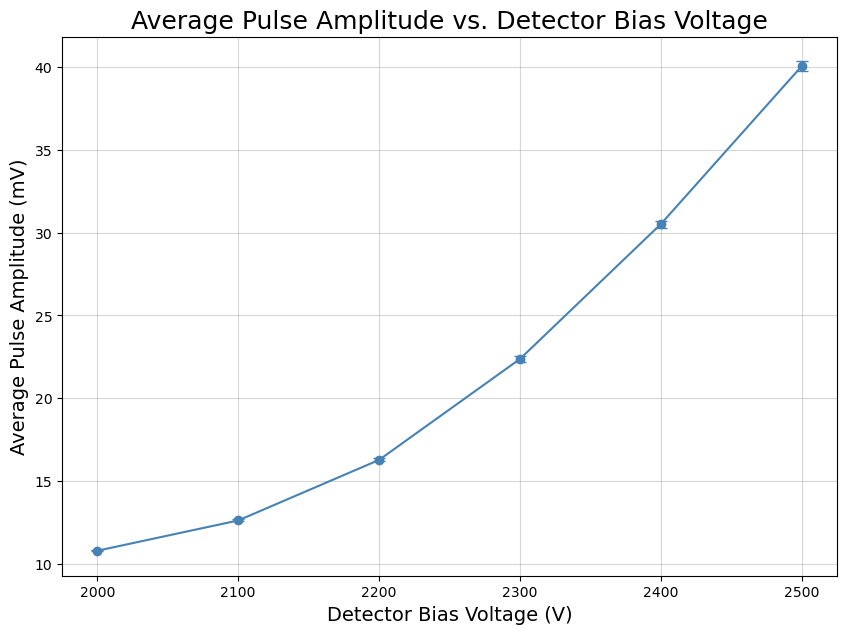

In [7]:
"""
Figure A.2: Average Pulse Amplitude vs. Detector Bias Voltage
----------------------------------------------------------------
Measured 29/06/26 on the oscilloscope (-7mV falling-edge trigger, average
acquisition mode with 512 sweeps, amplitude measurement, 4ns/10.0mV scale).
16 individual amplitude readings taken per bias setting; mean and SEM
computed directly from those 16 values.

Note: oscilloscope and TDC were connected in parallel without an active
signal splitter, so absolute amplitude values are qualitative only
(see §3.4.2 and Appendix A.1).
"""

amp_2000 = [10.77, 10.70, 10.71, 10.67, 10.71, 10.93, 11.02, 11.02, 10.80, 10.73, 10.68, 10.92, 10.76, 10.82, 10.76, 10.82]
amp_2100 = [12.48, 12.59, 12.67, 12.79, 12.60, 12.58, 12.39, 12.61, 13.03, 12.92, 12.92, 12.97, 12.40, 12.40, 12.30, 12.41]
amp_2200 = [15.65, 16.03, 16.17, 16.02, 16.10, 16.00, 16.06, 16.00, 16.18, 16.41, 16.55, 16.68, 16.86, 16.84, 16.64, 16.32]
amp_2300 = [20.67, 22.02, 21.65, 21.64, 21.86, 22.18, 22.39, 22.22, 22.64, 22.89, 22.85, 23.16, 23.06, 22.82, 22.85, 23.09]
amp_2400 = [28.64, 29.26, 29.34, 29.95, 30.47, 31.07, 30.54, 31.02, 30.84, 30.79, 30.36, 30.56, 31.06, 31.44, 31.62, 31.27]
amp_2500 = [37.20, 38.35, 38.40, 39.37, 39.90, 40.03, 40.49, 39.88, 40.61, 40.88, 40.87, 40.92, 41.14, 40.97, 40.84, 40.93]

biases = [2000, 2100, 2200, 2300, 2400, 2500]
amps_list = [amp_2000, amp_2100, amp_2200, amp_2300, amp_2400, amp_2500]

means = [np.mean(a) for a in amps_list]
sems = [np.std(a, ddof=1) / np.sqrt(len(a)) for a in amps_list]

plt.figure(figsize=(10, 7))
plt.errorbar(biases, means, yerr=sems, fmt='o-', color='steelblue', capsize=4)
plt.xlabel('Detector Bias Voltage (V)', fontsize=14)
plt.ylabel('Average Pulse Amplitude (mV)', fontsize=14)
plt.title('Average Pulse Amplitude vs. Detector Bias Voltage', fontsize=18)
plt.grid(alpha=0.5)
plt.show()

In [8]:
description = [
    "Average Detector Pulse Amplitude vs. Bias Voltage",
    "Corresponds to Figure A.2",
    "",
    "Purpose: an independent check that detector gain (secondary-electron",
    "multiplication per ion) increases with bias, using oscilloscope pulse",
    "amplitude rather than count rate. The oscilloscope and TDC were",
    "connected in parallel without an active signal splitter, so absolute",
    "amplitude values should be treated as qualitative rather than precisely",
    "calibrated.",
    "",
    "Oscilloscope settings: -7mV falling edge trigger, average acquisition mode",
    "(512 sweeps), amplitude measurement, 4ns/10.0mV scale.",
    "Each bias voltage's mean and SEM computed from 16 individual measurements.",
    "",
    "Columns:",
    "  bias_volts        - Detector bias voltage (V)",
    "  mean_amplitude_mv - Mean pulse amplitude across 16 measurements (mV)",
    "  sem_amplitude_mv  - Standard error of the mean (mV)",
    "  n_measurements    - Number of individual measurements averaged",
]

ns = [len(a) for a in amps_list]

export_df = pd.DataFrame({
    "bias_volts": biases,
    "mean_amplitude_mv": means,
    "sem_amplitude_mv": sems,
    "n_measurements": ns,
})

export_figure_csv(export_df, "thesis/pulse_height_vs_bias.csv", description)
print(export_df)

   bias_volts  mean_amplitude_mv  sem_amplitude_mv  n_measurements
0        2000          10.801250          0.028532              16
1        2100          12.628750          0.058437              16
2        2200          16.281875          0.087026              16
3        2300          22.374375          0.170878              16
4        2400          30.514375          0.209237              16
5        2500          40.048750          0.290886              16


In [9]:
import shutil

# Figure 3.4 - Detector Bias Voltage Scan
archive_raw_files(run8["file"].tolist(), "HVControl", "detector_bias_scan")

Copied 31 files to thesis/raw/detector_bias_scan


(['HV2600_8.mpa',
  'HV2580_8.mpa',
  'HV2560_8.mpa',
  'HV2540_8.mpa',
  'HV2520_8.mpa',
  'HV2500_8.mpa',
  'HV2480_8.mpa',
  'HV2460_8.mpa',
  'HV2440_8.mpa',
  'HV2420_8.mpa',
  'HV2400_8.mpa',
  'HV2380_8.mpa',
  'HV2360_8.mpa',
  'HV2340_8.mpa',
  'HV2320_8.mpa',
  'HV2300_8.mpa',
  'HV2280_8.mpa',
  'HV2260_8.mpa',
  'HV2240_8.mpa',
  'HV2220_8.mpa',
  'HV2200_8.mpa',
  'HV2180_8.mpa',
  'HV2160_8.mpa',
  'HV2140_8.mpa',
  'HV2120_8.mpa',
  'HV2100_8.mpa',
  'HV2080_8.mpa',
  'HV2060_8.mpa',
  'HV2040_8.mpa',
  'HV2020_8.mpa',
  'HV2000_8.mpa'],
 [])